# Analysis of Chest X-Ray images

Neural networks have revolutionised image processing in several different domains. Among these is the field of medical imaging. In the following notebook, we will get some hands-on experience in working with Chest X-Ray (CXR) images.

The objective of this exercise is to identify images where an "effusion" is present. This is a classification problem, where we will be dealing with two classes - 'effusion' and 'nofinding'. Here, the latter represents a "normal" X-ray image.

This same methodology can be used to spot various other illnesses that can be detected via a chest x-ray. For the scope of this demonstration, we will specifically deal with "effusion".

#1. Data Pre-processing

Our data is in the form of grayscale (black and white) images of chest x-rays. To perform our classification task effectively, we need to perform some pre-processing of the data.

First, we load all the relevant libraries.

In [24]:
import tensorflow as tf
from tensorflow import keras
from skimage import io
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.simplefilter('ignore')

Point a variable to the path where the data resides. Note that to use the code below you will need to move the folders effusion/ and nofinding/ into one common folder. You can do something like this:

mkdir CXR_Data
move effusion CXR_Data
move nofinding CXR_Data

In [25]:
!pip install kagglehub -q

import kagglehub

path = kagglehub.dataset_download("sarodeankur/cxr-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cxr-data' dataset.
Path to dataset files: /kaggle/input/cxr-data


In [26]:
import os

path = "/root/.cache/kagglehub/datasets/sarodeankur/cxr-data/versions/1"

# check what's actually inside first
print(os.listdir(path))

['CXR_data']


In [27]:
print(os.listdir(os.path.join(path, "CXR_data")))

['nofinding', 'effusion']


In [28]:
import shutil

src = os.path.join(path, "CXR_data")
dst = "./CXR_data"

if not os.path.exists(dst):
    shutil.copytree(src, dst)

print(os.listdir(dst))

['nofinding', 'effusion']


In [29]:
DATASET_PATH = './CXR_data'

# There are two classes of images that we will deal with
disease_cls = ['effusion', 'nofinding']

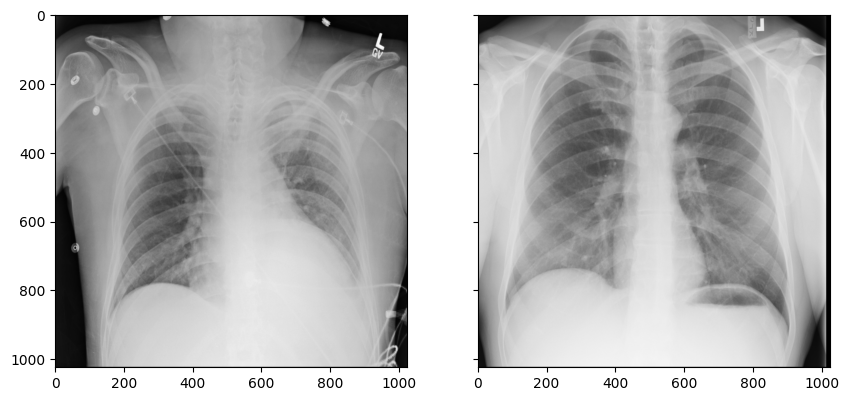

In [30]:
effusion_path = os.path.join(DATASET_PATH, disease_cls[0], '*')
effusion = glob.glob(effusion_path)
effusion = io.imread(effusion[0])

normal_path = os.path.join(DATASET_PATH, disease_cls[1], '*')
normal = glob.glob(normal_path)
normal = io.imread(normal[0])

f, axes = plt.subplots(1, 2, sharey=True)
f.set_figwidth(10)

axes[0].imshow(effusion, cmap='gray')
axes[1].imshow(normal, cmap='gray')

In [31]:
effusion.shape

(1024, 1024)

In [32]:
normal.shape

(1024, 1024)

#Data Augmentation

Now that we have read the images, the next step is data augmentation. We use the concept of a "data generator" that you learnt in the last section.

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=10,
    width_shift_range=0,
    height_shift_range=0,
    vertical_flip=False)

def preprocess_img(img, mode):
    img = (img - img.min()) / (img.max() - img.min())

    # handle both grayscale (2D) and color (3D) images safely
    if img.ndim == 3:
        img = rescale(img, 0.25, channel_axis=-1, mode='constant')
    else:
        img = rescale(img, 0.25, mode='constant')

    if mode == 'train':
        if np.random.randn() > 0:
            img = datagen.random_transform(img)
    return img

#2. Model building

We will be using a Resnet in this (you learnt about Resnets previously).

For this to work, the script that defines the resnet model (resnet.py) should reside in the same folder as this notebook.

In [34]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

img_channels = 1
img_rows = 256
img_cols = 256
nb_classes = 2

class AugmentedDataGenerator(keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, mode='train', ablation=None, disease_cls=['nofinding', 'effusion'],
                 batch_size=32, dim=(256, 256), n_channels=1, shuffle=True):
        self.dim = dim
        self.batch_size = batch_size
        self.labels = {}
        self.list_IDs = []
        self.mode = mode

        for i, cls in enumerate(disease_cls):
            paths = glob.glob(os.path.join(DATASET_PATH, cls, '*'))
            brk_point = int(len(paths) * 0.8)
            if self.mode == 'train':
                paths = paths[:brk_point]
            else:
                paths = paths[brk_point:]
            if ablation is not None:
                paths = paths[:int(len(paths) * ablation / 100)]
            self.list_IDs += paths
            self.labels.update({p: i for p in paths})

        self.n_channels = n_channels
        self.n_classes = len(disease_cls)
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        list_IDs_temp = [self.list_IDs[k] for k in indexes]
        X, y = self.__data_generation(list_IDs_temp)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_IDs_temp):
        X = np.empty((self.batch_size, *self.dim, self.n_channels))
        y = np.empty((self.batch_size), dtype=int)
        delete_rows = []

        for i, ID in enumerate(list_IDs_temp):
            img = io.imread(ID)
            img = img[:, :, np.newaxis]
            if img.shape == (1024, 1024, 1):
                img = preprocess_img(img, self.mode)
                X[i,] = img
                y[i] = self.labels[ID]
            else:
                delete_rows.append(i)
                continue

        X = np.delete(X, delete_rows, axis=0)
        y = np.delete(y, delete_rows, axis=0)

        return X, keras.utils.to_categorical(y, num_classes=self.n_classes)

In [35]:
base_model = keras.applications.ResNet50(
    include_top=False,
    weights=None,  # set to 'imagenet' if you want pretrained weights (requires 3-channel input though)
    input_shape=(img_rows, img_cols, img_channels),
    pooling='avg'
)

x = base_model.output
outputs = keras.layers.Dense(nb_classes, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      3,200 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,585,538 (89.97 MB)

 Trainable params: 23,532,418 (89.77 MB)

 Non-trainable params: 53,120 (207.50 KB)

#3. Ablation Run

In the previous notebook, you learnt about Ablation. Briefly, an ablation run is when you systematically modify certain parts of the input, in order to observe the equivalent change in the input.

For the following section, we'll be using the Data Generator concept that you previously worked on.

In [36]:
def resnet18_basic_block(x, filters, stride=1, conv_shortcut=False, name=None):
    shortcut = x
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                                  name=name + '_shortcut_conv')(x)
        shortcut = layers.BatchNormalization(name=name + '_shortcut_bn')(shortcut)

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', name=name + '_conv1')(x)
    x = layers.BatchNormalization(name=name + '_bn1')(x)
    x = layers.Activation('relu', name=name + '_relu1')(x)

    x = layers.Conv2D(filters, 3, strides=1, padding='same', name=name + '_conv2')(x)
    x = layers.BatchNormalization(name=name + '_bn2')(x)

    x = layers.Add(name=name + '_add')([shortcut, x])
    x = layers.Activation('relu', name=name + '_out')(x)
    return x

def build_resnet_18(input_shape, num_classes):
    channels, rows, cols = input_shape
    inputs = keras.Input(shape=(rows, cols, channels))

    x = layers.Conv2D(64, 7, strides=2, padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same', name='pool1')(x)

    filters_list = [64, 128, 256, 512]
    for stage, filters in enumerate(filters_list):
        for block in range(2):
            stride = 2 if (stage > 0 and block == 0) else 1
            conv_shortcut = (block == 0)
            x = resnet18_basic_block(x, filters, stride=stride,
                                      conv_shortcut=conv_shortcut,
                                      name=f'stage{stage}_block{block}')

    x = layers.GlobalAveragePooling2D(name='avgpool')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='fc')(x)

    model = keras.Model(inputs, outputs, name='resnet18')
    return model

In [37]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import *

class roc_callback(Callback):
    def on_train_begin(self, logs={}):
        logs['val_auc'] = 0

    def on_epoch_end(self, epoch, logs={}):
        y_p = []
        y_v = []
        for i in range(len(validation_generator)):
            x_val, y_val = validation_generator[i]
            y_pred = self.model.predict(x_val)
            y_p.append(y_pred)
            y_v.append(y_val)
        y_p = np.concatenate(y_p)
        y_v = np.concatenate(y_v)
        roc_auc = roc_auc_score(y_v, y_p)
        print('\nVal AUC for epoch {}: {}'.format(epoch, roc_auc))
        logs['val_auc'] = roc_auc

In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [39]:
from skimage.transform import rescale

In [40]:
model = build_resnet_18((img_channels, img_rows, img_cols), nb_classes)
model.compile(loss='categorical_crossentropy', optimizer='SGD',
              metrics=['accuracy'])

training_generator = AugmentedDataGenerator('train', ablation=20)
validation_generator = AugmentedDataGenerator('val', ablation=20)

auc_logger = roc_callback()

model.fit(training_generator,
          validation_data=validation_generator,
          epochs=5, callbacks=[auc_logger])

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Val AUC for epoch 0: 0.5287356321839081
5/5 ━━━━━━━━━━━━━━━━━━━━ 108s 21s/step - accuracy: 0.7389 - loss: 0.4884 - val_accuracy: 0.9062 - val_loss: 0.6533 - val_auc: 0.5287
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Val AUC for epoch 1: 0.6896551724137931
5/5 ━━━━━━━━━━━━━━━━━━━━ 83s 16s/step - accuracy: 0.9172 - loss: 0.2844 - val_accuracy: 0.9032 - val_loss: 0.6223 - val_auc: 0.6897
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Val AUC for epoch 2: 0.7068965517241379
5/5 ━━━━━━━━━━━━━━━━━━━━ 87s 18s/step - accuracy: 0.9045 - loss: 0.2818 - val_accuracy: 0.9032 - val_loss: 0.5784 - val_auc: 0.7069
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Val AUC for epoch 3: 0.47619047619047616
5/5 ━━━━━━━━━━━━━━━━━━━━ 107s 23s/step - accuracy: 0.9172 - loss: 0.2477 - val_accuracy: 0.9062 - val_loss: 0.5485 - val_auc: 0.4762
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Val AUC for epoch 4: 0.6333333333333333
5/5 ━━━━━━━━━━━━━━━━━━━━ 103s 20s/

In [46]:
from functools import partial
from tensorflow.keras import backend as K
from itertools import product

def w_categorical_crossentropy(y_true, y_pred, weights):
    nb_cl = len(weights)
    final_mask = K.zeros_like(y_pred[:, 0])
    y_pred_max = K.max(y_pred, axis=1)
    y_pred_max = K.reshape(y_pred_max, (K.shape(y_pred)[0], 1))
    y_pred_max_mat = K.cast(K.equal(y_pred, y_pred_max), K.floatx())
    for c_p, c_t in product(range(nb_cl), range(nb_cl)):
        final_mask += (weights[c_t, c_p] * y_pred_max_mat[:, c_p] * y_true[:, c_t])
    cross_ent = K.categorical_crossentropy(y_true, y_pred, from_logits=False)
    return cross_ent * final_mask

bin_weights = np.ones((2, 2))
bin_weights[0, 1] = 5
bin_weights[1, 0] = 5
ncce = partial(w_categorical_crossentropy, weights=bin_weights)
ncce.__name__ = 'w_categorical_crossentropy'

In [47]:
model = build_resnet_18((img_channels, img_rows, img_cols), nb_classes)
model.compile(loss=ncce, optimizer='SGD',
              metrics=['accuracy'])

training_generator = AugmentedDataGenerator('train', ablation=5)
validation_generator = AugmentedDataGenerator('val', ablation=5)

model.fit(training_generator,
          validation_data=None,
          epochs=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - accuracy: 0.0938 - loss: 14.2126


In [50]:
filepath = 'models/best_model.keras'

In [48]:
import os
os.makedirs('models', exist_ok=True)

class DecayLR(keras.callbacks.Callback):
    def __init__(self, base_lr=0.01, decay_epoch=1):
        super(DecayLR, self).__init__()
        self.base_lr = base_lr
        self.decay_epoch = decay_epoch
        self.lr_history = []

    def on_train_begin(self, logs={}):
        self.model.optimizer.learning_rate.assign(self.base_lr)

    def on_epoch_end(self, epoch, logs={}):
        new_lr = self.base_lr * (0.5 ** (epoch // self.decay_epoch))
        self.lr_history.append(float(self.model.optimizer.learning_rate.numpy()))
        self.model.optimizer.learning_rate.assign(new_lr)

In [51]:
import os
os.makedirs('models', exist_ok=True)

model = build_resnet_18((img_channels, img_rows, img_cols), nb_classes)
sgd = optimizers.SGD(learning_rate=0.005)

bin_weights = np.ones((2, 2))
bin_weights[1, 1] = 10
bin_weights[1, 0] = 10
ncce = partial(w_categorical_crossentropy, weights=bin_weights)
ncce.__name__ = 'w_categorical_crossentropy'

model.compile(loss=ncce, optimizer=sgd,
              metrics=['accuracy'])

training_generator = AugmentedDataGenerator('train', ablation=50)
validation_generator = AugmentedDataGenerator('val', ablation=50)

auc_logger = roc_callback()
filepath = 'models/best_model.keras'
checkpoint = ModelCheckpoint(filepath, monitor='val_auc', verbose=1, save_best_only=True, mode='max')
decay = DecayLR()

model.fit(training_generator,
          validation_data=validation_generator,
          epochs=10, callbacks=[auc_logger, decay, checkpoint])

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.4543 - loss: 2.2531 

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Val AUC for epoch 0: 0.6518883415435139

Epoch 1: val_auc improved from None to 0.65189, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 234s 17s/step - accuracy: 0.5037 - loss: 2.4550 - val_accuracy: 0.1064 - val_loss: 1.3651 - val_auc: 0.6519
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Val AUC for epoch 1: 0.5699346405228758

Epoch 2: val_auc did not improve from 0.65189
13/13 ━━━━━━━━━━━━━━━━━━━━ 207s 16s/step - accuracy: 0.5602 - loss: 2.0628 - val_accuracy: 0.2021 - val_loss: 1.3883 - val_auc: 0.5699
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Val AUC for epoch 2: 0.642935377875137

Epoch 3: val_auc did not improve from 0.65189
13/13 ━━━━━━━━━━━━━━━━━━━━ 208s 16s/step - accuracy: 0.6

In [52]:
val_model = build_resnet_18((img_channels, img_rows, img_cols), nb_classes)
val_model.load_weights('models/best_model.keras')

#5. Making a Prediction

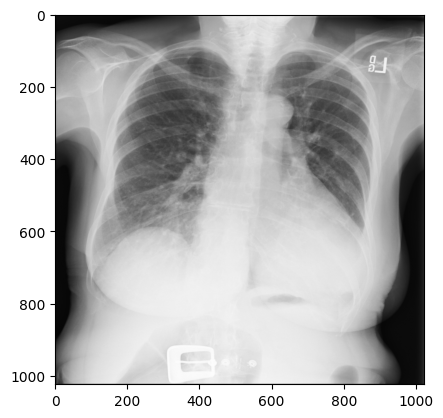

In [53]:
effusion_path = os.path.join(DATASET_PATH, disease_cls[0], '*')
effusion = glob.glob(effusion_path)
effusion = io.imread(effusion[-8])
plt.imshow(effusion, cmap='gray')

In [54]:
img = preprocess_img(effusion[:, :, np.newaxis], 'validation')
prediction = val_model.predict(img[np.newaxis, :])
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.79938835 0.20061167]]


In [55]:
predicted_idx = np.argmax(prediction)
predicted_class = disease_cls[predicted_idx]
confidence = prediction[0][predicted_idx]

print(f"Predicted class: {predicted_class} (confidence: {confidence:.2%})")

Predicted class: effusion (confidence: 79.94%)
